In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nexon4ik/knowledge-bench-public8989/knowledge_bench_public.csv
/kaggle/input/models/nexon4ik/lmaololkek/other/default/1/scaler.pkl
/kaggle/input/models/nexon4ik/lmaololkek/other/default/1/hallucination_detector.pkl
/kaggle/input/models/nexon4ik/lmaololkek/other/default/1/pca.pkl


In [2]:
!pip install -q bitsandbytes>=0.46.1
!pip install -q transformers accelerate bitsandbytes scikit-learn

# ========== Импорты ==========
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import gc
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
import joblib
import pickle
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [3]:
# ========== Конфигурация ==========
MODEL_NAME = "ai-sage/GigaChat3-10B-A1.8B-bf16"
BENCHMARK_CSV = "/kaggle/input/datasets/nexon4ik/knowledge-bench-public8989/knowledge_bench_public.csv"   # путь к бенчмарку
DETECTOR_PATH = "/kaggle/input/models/nexon4ik/lmaololkek/other/default/1/hallucination_detector.pkl"
PCA_PATH = "/kaggle/input/models/nexon4ik/lmaololkek/other/default/1/pca.pkl"
SCALER_PATH = "/kaggle/input/models/nexon4ik/lmaololkek/other/default/1/scaler.pkl"
OUTPUT_DIR = "/kaggle/working/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PROBE_LAYERS = [0,5,10,15,20,25]   # должны совпадать с обучением

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

# ========== Загрузка LLM (8-bit) ==========
print("Загрузка GigaChat...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_enable_fp32_cpu_offload=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,
    offload_folder="offload",
)
model.eval()
print("LLM загружена")

Загрузка GigaChat...


config.json: 0.00B [00:00, ?B/s]

`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

...

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/363 [00:00<?, ?it/s]

DeepseekV3ForCausalLM LOAD REPORT from: ai-sage/GigaChat3-10B-A1.8B-bf16
Key                                                 | Status     |  | 
----------------------------------------------------+------------+--+-
model.layers.26.mlp.shared_experts.up_proj.weight   | UNEXPECTED |  | 
model.layers.26.mlp.shared_experts.down_proj.weight | UNEXPECTED |  | 
model.layers.26.mlp.shared_experts.gate_proj.weight | UNEXPECTED |  | 
model.layers.26.hnorm.weight                        | UNEXPECTED |  | 
model.layers.26.self_attn.kv_b_proj.weight          | UNEXPECTED |  | 
model.layers.26.mlp.experts.gate_up_proj            | UNEXPECTED |  | 
model.layers.26.self_attn.kv_a_proj_with_mqa.weight | UNEXPECTED |  | 
model.layers.26.self_attn.kv_a_layernorm.weight     | UNEXPECTED |  | 
model.layers.26.self_attn.q_proj.weight             | UNEXPECTED |  | 
model.layers.26.self_attn.o_proj.weight             | UNEXPECTED |  | 
model.layers.26.mlp.experts.down_proj               | UNEXPECTED |  | 
mode

generation_config.json:   0%|          | 0.00/153 [00:00<?, ?B/s]

LLM загружена


In [4]:
# ========== Загрузка детектора и трансформеров ==========
detector = joblib.load(DETECTOR_PATH)
with open(PCA_PATH, 'rb') as f:
    pca = pickle.load(f)
with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)
print("Детектор и трансформеры загружены")

Детектор и трансформеры загружены


In [5]:
# ========== Класс FeatureAccumulator (копия из обучения) ==========
class FeatureAccumulator:
    def __init__(self, model, probe_layers):
        self.model = model
        self.probe_layers = probe_layers
        self._hooks = []
        self._hidden = {}
    def attach(self):
        self._hidden.clear()
        layers = self.model.model.layers
        for idx in self.probe_layers:
            if idx >= len(layers): continue
            name = f"layer_{idx}"
            def make_hook(n):
                def hook(_, __, out):
                    h = out[0] if isinstance(out, tuple) else out
                    self._hidden[n] = h.detach()
                return hook
            self._hooks.append(layers[idx].register_forward_hook(make_hook(name)))
    def detach(self):
        for h in self._hooks: h.remove()
        self._hooks.clear()
    def __enter__(self):
        self.attach()
        return self
    def __exit__(self, *args):
        self.detach()
    def compute_features(self, logits, input_ids, ans_start):
        seq_len = input_ids.shape[1]
        ans_len = seq_len - ans_start
        answer_logits = logits[0, ans_start-1:seq_len-1, :].float()
        answer_ids = input_ids[0, ans_start:seq_len]
        answer_ids = answer_ids.to(answer_logits.device)

        log_probs = F.log_softmax(answer_logits, dim=-1)
        token_lp = log_probs.gather(1, answer_ids.unsqueeze(1)).squeeze(-1)

        probs = F.softmax(answer_logits, dim=-1)
        entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=-1)
        top1 = probs.max(dim=-1).values
        top5 = probs.topk(min(5, probs.shape[-1]), dim=-1).values.sum(dim=-1)

        uncertainty = np.array([
            token_lp.mean().item(), token_lp.min().item(), token_lp.max().item(),
            token_lp.std().item() if ans_len > 1 else 0.0,
            entropy.mean().item(), entropy.max().item(),
            entropy.std().item() if ans_len > 1 else 0.0,
            torch.exp(-token_lp.mean()).item(), float(ans_len), token_lp[0].item(),
            top1.mean().item(), top5.mean().item()
        ], dtype=np.float32)

        last_hs = self._hidden[f"layer_{self.probe_layers[-1]}"][0]
        probe_vec = last_hs[ans_start-1].cpu().float().numpy()

        int_scalars = []
        for idx in self.probe_layers:
            hs = self._hidden[f"layer_{idx}"][0]
            int_scalars.append(hs[ans_start-1].norm().item())
            int_scalars.append(hs[ans_start:seq_len].norm(dim=-1).mean().item())

            ans_hs = hs[ans_start-1:seq_len-1].unsqueeze(0)
            with torch.no_grad():
                norm_hs = self.model.model.norm(ans_hs)
                ll = self.model.lm_head(norm_hs).float()
            ll_p = torch.softmax(ll[0], dim=-1)
            ll_e = -(ll_p * torch.log(ll_p + 1e-10)).sum(dim=-1)
            int_scalars.append(ll_e.mean().item())

        first_e, last_e = int_scalars[2], int_scalars[-1]
        int_scalars.append(first_e - last_e)
        int_scalars.append(last_e / (first_e + 1e-10))

        internal = np.array(int_scalars, dtype=np.float32)
        self._hidden.clear()
        return {"uncertainty": uncertainty, "internal_scalars": internal, "probe_vec": probe_vec}

In [6]:
# ========== Загрузка бенчмарка ==========
df = pd.read_csv(BENCHMARK_CSV)
print(f"Бенчмарк содержит {len(df)} примеров")

# ========== Функция препроцессинга (идентичная обучению) ==========
def preprocess(tokenizer, prompt, answer):
    prompt_enc = tokenizer.apply_chat_template([{"role":"user","content":prompt}], add_generation_prompt=True, tokenize=True)
    ans_start = len(prompt_enc["input_ids"])
    full_enc = tokenizer.apply_chat_template([{"role":"user","content":prompt},{"role":"assistant","content":answer}], tokenize=True)
    tok_ids = torch.tensor([full_enc["input_ids"]], dtype=torch.long)
    return tok_ids, ans_start

# ... в цикле:
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Обработка примеров"):
    question = row['prompt']
    prompt = f"Вопрос: {question}\n\nОтвет:"
    answer = row['model_answer']
    
    tok_ids, ans_start = preprocess(tokenizer, prompt, answer)

Бенчмарк содержит 1044 примеров



Обработка примеров: 100%|██████████| 1044/1044 [00:06<00:00, 164.50it/s]


In [7]:
# ========== Инференс с прогресс-баром ==========
accumulator = FeatureAccumulator(model, PROBE_LAYERS)

predictions = []
probabilities = []
detection_times = []
true_labels = df['is_hallucination'].values  # True/False -> 1/0

# Используем tqdm для отображения прогресса
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Обработка примеров"):
    prompt = row['prompt']
    answer = row['model_answer']
    
    # Токенизация
    tok_ids, ans_start = preprocess(tokenizer, prompt, answer)
    tok_ids = tok_ids.to(model.device)
    
    # Forward pass (не засекаем)
    with accumulator, torch.no_grad():
        outputs = model(tok_ids)
    
    # Извлечение признаков (входит в детекцию)
    start_time = time.perf_counter()
    features = accumulator.compute_features(outputs.logits, tok_ids, ans_start)
    
    # Преобразование признаков
    probe_pca = pca.transform(features["probe_vec"].reshape(1, -1))   # PCA
    X = np.hstack([probe_pca, features["internal_scalars"].reshape(1, -1), features["uncertainty"].reshape(1, -1)])
    X_scaled = scaler.transform(X)
    
    # Предсказание вероятности
    prob = detector.predict_proba(X_scaled)[0, 1]
    detection_time = time.perf_counter() - start_time
    detection_times.append(detection_time)
    
    probabilities.append(prob)
    predictions.append(1 if prob >= 0.5 else 0)
    
    # Очистка памяти
    del tok_ids, outputs
    torch.cuda.empty_cache()
    if (idx+1) % 50 == 0:
        gc.collect()

# ========== Метрики ==========
y_true = true_labels.astype(int)
y_pred = np.array(predictions)
y_proba = np.array(probabilities)

pr_auc = average_precision_score(y_true, y_proba)
roc_auc = roc_auc_score(y_true, y_proba)
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n===== Результаты на бенчмарке =====")
print(f"PR-AUC:            {pr_auc:.4f}")
print(f"ROC-AUC:           {roc_auc:.4f}")
print(f"Accuracy:          {acc:.4f}")
print(f"Precision:         {prec:.4f}")
print(f"Recall:            {rec:.4f}")
print(f"F1-score:          {f1:.4f}")

# ========== Время детекции ==========
avg_time = np.mean(detection_times) * 1000  # в миллисекундах
max_time = np.max(detection_times) * 1000
print(f"\n===== Время детекции (без forward pass) =====")
print(f"Среднее:   {avg_time:.2f} ms")
print(f"Максимум:  {max_time:.2f} ms")
print(f"Удовлетворяет <500 ms: {'ДА' if max_time < 500 else 'НЕТ'}")


Обработка примеров: 100%|██████████| 1044/1044 [10:43<00:00,  1.62it/s]


===== Результаты на бенчмарке =====
PR-AUC:            0.5376
ROC-AUC:           0.4859
Accuracy:          0.5421
Precision:         0.5423
Recall:            0.9965
F1-score:          0.7024

===== Время детекции (без forward pass) =====
Среднее:   68.65 ms
Максимум:  194.74 ms
Удовлетворяет <500 ms: ДА


In [8]:
# Сохраняем результаты
results_df = df.copy()
results_df['predicted_hallucination'] = y_pred
results_df['probability'] = y_proba
results_df['detection_time_ms'] = np.array(detection_times) * 1000
results_df.to_csv(OUTPUT_DIR + "benchmark_predictions.csv", index=False)
print(f"\nРезультаты сохранены в {OUTPUT_DIR}benchmark_predictions.csv")


Результаты сохранены в /kaggle/working/benchmark_predictions.csv


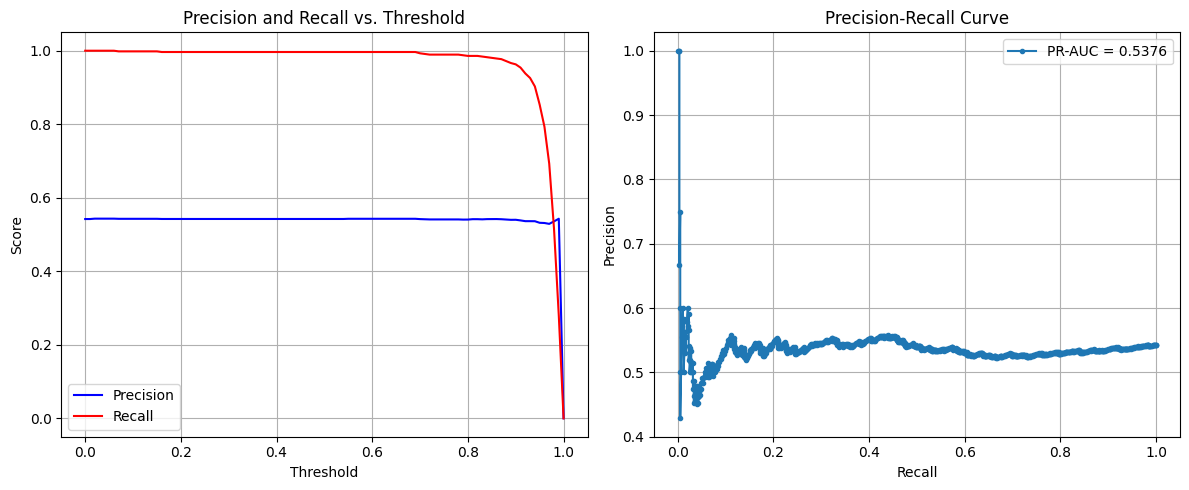

PR-AUC = 0.5376
Оптимальный порог по F1: 0.02 (F1 = 0.7040)


In [9]:
# Предполагается, что у вас есть:
# y_true  - массив истинных меток (0/1)
# y_proba - массив предсказанных вероятностей класса 1

# 1. PR-кривая и PR-AUC
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_true, y_proba)
pr_auc = average_precision_score(y_true, y_proba)

# 2. Для графика precision/recall от порога (бинарные пороги от 0 до 1)
thresholds = np.linspace(0, 1, 101)
precisions = []
recalls = []
for th in thresholds:
    y_pred = (y_proba >= th).astype(int)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precisions.append(precision)
    recalls.append(recall)

# Построение графиков
plt.figure(figsize=(12, 5))

# График 1: Precision и Recall от порога
plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions, label='Precision', color='blue')
plt.plot(thresholds, recalls, label='Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs. Threshold')
plt.legend()
plt.grid(True)

# График 2: PR-кривая
plt.subplot(1, 2, 2)
plt.plot(recall_curve, precision_curve, marker='.', label=f'PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Дополнительно: вывести оптимальный порог по F1-score
f1_scores = [2 * p * r / (p + r) if (p + r) > 0 else 0 for p, r in zip(precisions, recalls)]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"PR-AUC = {pr_auc:.4f}")
print(f"Оптимальный порог по F1: {best_threshold:.2f} (F1 = {best_f1:.4f})")

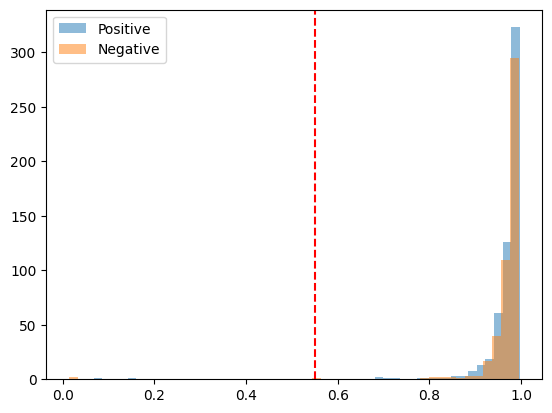

In [10]:
plt.hist(y_proba[y_true==1], bins=50, alpha=0.5, label='Positive')
plt.hist(y_proba[y_true==0], bins=50, alpha=0.5, label='Negative')
plt.axvline(x=0.55, color='red', linestyle='--')
plt.legend()
plt.show()